##**1. Import Library**

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans

##**2. Upload dan Membaca Dataset**

In [2]:
from google.colab import files

uploaded = files.upload()

Saving Copy of Data Pelanggan Shopee.xlsx to Copy of Data Pelanggan Shopee (1).xlsx


In [3]:
df = pd.read_excel("/content/Copy of Data Pelanggan Shopee.xlsx")
df.head()

,ID Customer,Jenis kelamin,Produk,Total Belanja,Metode Pembayaran,Rating pelanggan,Kota,Rata rata Transaksi,Frekuensi Order,Total Produk
0,lutviana.s,Perempuan,Kerangka Buket Kosongan wisuda Barang Uang,98400,QRIS,5,Bali,32800,3,3
1,4mndmo3s3_,Laki-Laki,Kerangka Buket Kosongan wisuda Barang Uang,532600,Online Payment,5,Bali,266300,2,14
2,ijahukong1w,Laki-Laki,Kerangka Buket Kosongan wisuda Barang Uang,13779,COD,4,Jawa Barat,13779,1,1
3,mardiahsondang03,Perempuan,Bunga Mawar Pita Satin Premium Maroon Hitam,31625,COD,5,Sumatera Selatan,31625,1,1
4,44morr66,Laki-Laki,Bunga Mawar Pita Satin Premium Maroon Hitam,35200,QRIS,5,Jawa tengah,17600,2,6


##**3. Melihat Informasi Dataset (Preprocessing Data)**


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID Customer          50 non-null     object
 1   Jenis kelamin        50 non-null     object
 2   Produk               50 non-null     object
 3   Total Belanja        50 non-null     int64 
 4   Metode Pembayaran    50 non-null     object
 5   Rating pelanggan     50 non-null     int64 
 6   Kota                 50 non-null     object
 7   Rata rata Transaksi  50 non-null     int64 
 8   Frekuensi Order      50 non-null     int64 
 9   Total Produk         50 non-null     int64 
dtypes: int64(5), object(5)
memory usage: 4.0+ KB


In [5]:
df.describe()

,Total Belanja,Rating pelanggan,Rata rata Transaksi,Frekuensi Order,Total Produk
count,50.000000,50.000000,50.000000,50.000000,50.000000
mean,39476.320000,4.720000,30436.600000,1.160000,2.760000
std,75329.290252,0.729551,40287.672113,0.421852,2.825251
min,5340.000000,1.000000,5340.000000,1.000000,1.000000
25%,16606.250000,5.000000,16425.000000,1.000000,1.000000
50%,20805.000000,5.000000,19600.000000,1.000000,1.000000
75%,34537.500000,5.000000,29426.000000,1.000000,3.750000
max,532600.000000,5.000000,266300.000000,3.000000,14.000000


*Cek Missing Value*

In [6]:
df.isnull().sum()

,0
ID Customer,0
Jenis kelamin,0
Produk,0
Total Belanja,0
Metode Pembayaran,0
Rating pelanggan,0
Kota,0
Rata rata Transaksi,0
Frekuensi Order,0
Total Produk,0


Diperoleh pada seluruh atribut pada dataset tidak memiliki data yang hilang atau missing value. Hal ini menunjukkan bahwa data lengkap.

Seleksi Variabel/Atribut yang akan digunakan

In [7]:
X = df[['Total Belanja',
        'Frekuensi Order',
        'Rata rata Transaksi',
        'Total Produk',
        'Rating pelanggan']]

In [8]:
#Cek Hasil
X.head()

,Total Belanja,Frekuensi Order,Rata rata Transaksi,Total Produk,Rating pelanggan
0,98400,3,32800,3,5
1,532600,2,266300,14,5
2,13779,1,13779,1,4
3,31625,1,31625,1,5
4,35200,2,17600,6,5


##**4. Normalisasi Data**

proses normalisasi dilakukan dengan menggunakan metode Min-Max Scaling.
Metode ini mentransformasikann nilai setiap variabel kedalam rentang 0 sampai 1.

In [9]:
scaler = MinMaxScaler()

X_scaled = scaler.fit_transform(X)

In [10]:
##Lihat Hasil
pd.DataFrame(X_scaled,
             columns=X.columns).head()

,Total Belanja,Frekuensi Order,Rata rata Transaksi,Total Produk,Rating pelanggan
0,0.176497,1.0,0.105227,0.153846,1.00
1,1.000000,0.5,1.000000,1.000000,1.00
2,0.016005,0.0,0.032338,0.000000,0.75
3,0.049852,0.0,0.100724,0.000000,1.00
4,0.056632,0.5,0.046980,0.384615,1.00


*Perbandingan data sebelum dan sesudah normalisasi*

In [11]:
# Data sebelum normalisasi
before = X.agg(['min','max']).T

# Data sesudah normalisasi
after = pd.DataFrame(
    X_scaled,
    columns=X.columns
).agg(['min','max']).T

# Gabungkan
comparison = pd.DataFrame({
    'Min Sebelum': before['min'],
    'Max Sebelum': before['max'],
    'Min Sesudah': after['min'],
    'Max Sesudah': after['max']
})

comparison

,Min Sebelum,Max Sebelum,Min Sesudah,Max Sesudah
Total Belanja,5340,532600,0.0,1.0
Frekuensi Order,1,3,0.0,1.0
Rata rata Transaksi,5340,266300,0.0,1.0
Total Produk,1,14,0.0,1.0
Rating pelanggan,1,5,0.0,1.0


*Cek sudah benar atau belum bagian prepocessing dan normalisasi data*

In [12]:
pd.DataFrame(X_scaled, columns=X.columns).isnull().sum()

,0
Total Belanja,0
Frekuensi Order,0
Rata rata Transaksi,0
Total Produk,0
Rating pelanggan,0


##**5. Penentuan Jumlah Cluster (Elbow Method)**

Penentuan jumlah cluster dilakukan menggunakan metode Elbow Method untuk memperoleh jumlah cluster yang optimal pada proses K-Means. Metode ini diakukan dengan menghitung nilai Within Cluster Sum of Square (WCSS)pada beberapa jumlah cluster yang berbeda.
Semakin kecil nilai WCSS menunjuukan anggota dalam cluster memiliki tingkat kemiripan yang lebih tinggi.

In [13]:
wcss = []


X_scaled_imputed = np.copy(X_scaled)
X_scaled_imputed[np.isnan(X_scaled_imputed[:, 4]), 4] = 1.0

for i in range(1,11):
    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled_imputed) # Use the imputed data

    wcss.append(kmeans.inertia_)

In [14]:
import pandas as pd

tabel_wcss = pd.DataFrame({
    'Jumlah Cluster (K)': range(1,11),
    'WCSS': wcss
})

print(tabel_wcss)

   Jumlah Cluster (K)      WCSS
0                   1  8.292355
1                   2  5.618402
2                   3  3.785575
3                   4  2.591947
4                   5  1.685119
5                   6  1.373378
6                   7  1.080626
7                   8  0.834132
8                   9  0.622652
9                  10  0.398972


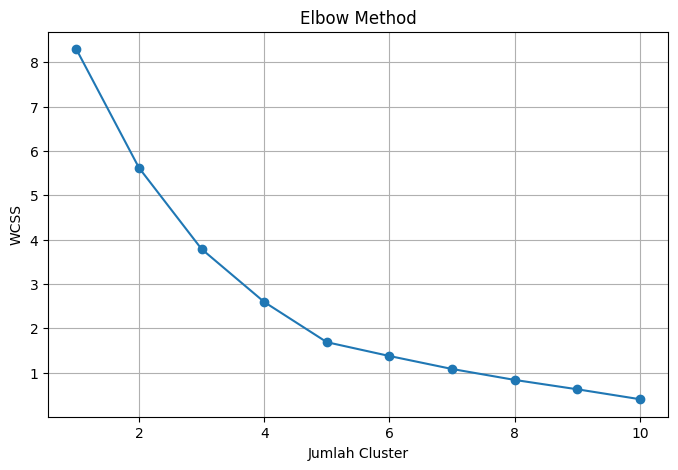

In [15]:
#Visualisasi
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.title('Elbow Method')
plt.xlabel('Jumlah Cluster')
plt.ylabel('WCSS')
plt.grid(True)

plt.show()

Dari hasil dan garfik di atas dapat dilihat bahwa nilai WCSS mengalami penurunan yang cukup signifikan dari K=1 hingga K=3. setelah K=3 nilai WCSS masih mengalami penurunan, namun besarnya relatif lebih kecil. Hal tersebut menunjukkan perubahan kemiringan kurva mulai terlihat pada K=3 sehingga titik tersebut terpilih sebagai Elbow Point.

##**6. Hasil Clustering (K-Means)**
Elbow Point menggunaan K=3

In [16]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

cluster = kmeans.fit_predict(X_scaled_imputed)

In [17]:
##tambahkan ke dataset
df['Cluster'] = cluster

In [18]:
##lihat hasil
df.head()

,ID Customer,Jenis kelamin,Produk,Total Belanja,Metode Pembayaran,Rating pelanggan,Kota,Rata rata Transaksi,Frekuensi Order,Total Produk,Cluster
0,lutviana.s,Perempuan,Kerangka Buket Kosongan wisuda Barang Uang,98400,QRIS,5,Bali,32800,3,3,2
1,4mndmo3s3_,Laki-Laki,Kerangka Buket Kosongan wisuda Barang Uang,532600,Online Payment,5,Bali,266300,2,14,1
2,ijahukong1w,Laki-Laki,Kerangka Buket Kosongan wisuda Barang Uang,13779,COD,4,Jawa Barat,13779,1,1,0
3,mardiahsondang03,Perempuan,Bunga Mawar Pita Satin Premium Maroon Hitam,31625,COD,5,Sumatera Selatan,31625,1,1,0
4,44morr66,Laki-Laki,Bunga Mawar Pita Satin Premium Maroon Hitam,35200,QRIS,5,Jawa tengah,17600,2,6,2


*Jumlah Anggota Tiap Cluster*

In [19]:
df['Cluster'].value_counts()


,count
Cluster,
0,43
2,6
1,1


Seluruh pelanggan berhasil dikelompokkan ke dalam 3 cluster.
Interpretasi:
1. Cluster 0 terdiri dari 43 pelanggan (86%).
2. Cluster 1 terdiri dari 1 pelanggan (2%).
3. Cluster 2 terdiri dari 6 pelanggan (12%).

In [20]:
df.groupby('Cluster')[[
    'Total Belanja',
    'Rata rata Transaksi',
    'Frekuensi Order',
    'Total Produk',
    'Rating pelanggan'
]].mean()

,Total Belanja,Rata rata Transaksi,Frekuensi Order,Total Produk,Rating pelanggan
Cluster,,,,,
0,26108.046512,25875.488372,1.000000,2.418605,4.720930
1,532600.000000,266300.000000,2.000000,14.000000,5.000000
2,53095.000000,23814.000000,2.166667,3.333333,4.666667


*Centroid Cluster*

Analisis centroid digunakan untuk mengetahui karakteristik masing-masing cluster.

In [21]:
pd.DataFrame(
    kmeans.cluster_centers_,
    columns=X.columns
)

,Total Belanja,Frekuensi Order,Rata rata Transaksi,Total Produk,Rating pelanggan
0,0.039389,-4.163336e-17,0.078692,0.109123,0.930233
1,1.000000,5.000000e-01,1.000000,1.000000,1.000000
2,0.090572,5.833333e-01,0.070792,0.179487,0.916667



1. Cluster 1 memiliki nilai centroid tertinggi pada sebagian besar variabel.
2. Cluster 0 memiliki nilai centroid terendah pada beberapa variabel.
3. Cluster 2 memiliki nilai centroid yang berada di antara Cluster 0 dan Cluster 1 pada beberapa variabel.

Output centroid inilah yang nantinya digunakan untuk
menentukan karakteristik Cluster 0, Cluster 1, dan Cluster 2.

*Evaluasi Kualitas Klaster dengan Silhouette Score*

Silhouette Score digunakan untuk mengukur seberapa mirip suatu objek dengan klaster sendiri dibandingkan dengan klaster lain. Nilai score berkisar dari -1 hingga 1, di mana:

1 Menunjukkan bahwa klaster terpisah dengan baik dan padat.

0 Menunjukkan bahwa klaster tumpang tindih.

-1 Menunjukkan bahwa objek telah ditempatkan di klaster yang salah.

In [22]:
from sklearn.metrics import silhouette_score

silhouette_avg = silhouette_score(X_scaled_imputed, cluster)
print(f"The average Silhouette Score is : {silhouette_avg:.3f}")

The average Silhouette Score is : 0.552


Dengan nilai Silhouette Score rata-rata **0.552**. Angka ini menunjukkan bahwa klaster-klaster yang terbentuk cukup terpisah dan memiliki kepadatan yang wajar. Meskipun bukan nilai yang sangat tinggi (mendekati 1, yang mengindikasikan pemisahan sempurna), skor ini menandakan bahwa struktur klaster yang dihasilkan oleh K-Means adalah masuk akal dan sebagian besar pelanggan telah dikelompokkan ke dalam klaster yang sesuai, dengan sedikit tumpang tindih atau penempatan yang salah. Ini adalah hasil yang cukup baik untuk analisis klastering.

##**7. Analisis Karakteristik Cluster**

In [23]:
cluster_summary = df.groupby('Cluster')[[
    'Total Belanja',
    'Frekuensi Order',
    'Rata rata Transaksi',
    'Total Produk',
    'Rating pelanggan'
]].mean()

cluster_summary

,Total Belanja,Frekuensi Order,Rata rata Transaksi,Total Produk,Rating pelanggan
Cluster,,,,,
0,26108.046512,1.000000,25875.488372,2.418605,4.720930
1,532600.000000,2.000000,266300.000000,14.000000,5.000000
2,53095.000000,2.166667,23814.000000,3.333333,4.666667


### **Interpretasi Hasil Klastering**

**1. Cluster 0: Pelanggan Hemat/Inaktif (43 Anggota)**

*   **Total Belanja**: Rata-rata paling rendah (sekitar 26.108).
*   **Frekuensi Order**: Paling rendah (rata-rata 1 kali order).
*   **Rata-rata Transaksi**: Paling rendah (sekitar 25.875).
*   **Total Produk**: Rata-rata paling rendah (sekitar 2.4 produk).
*   **Rating Pelanggan**: Cukup baik (rata-rata sekitar 4.7).

**Interpretasi:** Ini adalah klaster pelanggan dengan aktivitas belanja paling rendah. Mereka cenderung berbelanja dalam jumlah kecil, jarang melakukan pembelian, dan membeli sedikit produk. Meskipun demikian, rating pelanggan mereka cukup positif, menunjukkan bahwa mereka mungkin puas dengan pengalaman belanja mereka meskipun tidak sering berinteraksi.

**2. Cluster 1: Pelanggan VIP/Bernilai Sangat Tinggi (1 Anggota)**

*   **Total Belanja**: Jauh paling tinggi (sekitar 532.600).
*   **Frekuensi Order**: Moderat (2 kali order).
*   **Rata-rata Transaksi**: Jauh paling tinggi (sekitar 266.300).
*   **Total Produk**: Jauh paling tinggi (14 produk).
*   **Rating Pelanggan**: Sempurna (5.0).

**Interpretasi:** Klaster ini merepresentasikan satu pelanggan yang sangat bernilai (`high-value customer`). Meskipun frekuensi ordernya tidak yang paling banyak, nilai total belanja dan rata-rata transaksinya sangat dominan. Pelanggan ini membeli banyak produk dalam satu waktu dan memberikan rating sempurna. Ini adalah pelanggan yang sangat penting dan strategis.

**3. Cluster 2: Pelanggan Aktif Moderat (6 Anggota)**

*   **Total Belanja**: Menengah ke tinggi (sekitar 53.095).
*   **Frekuensi Order**: Paling tinggi (rata-rata 2.17 kali order).
*   **Rata-rata Transaksi**: Relatif rendah dibandingkan total belanja (sekitar 23.814).
*   **Total Produk**: Menengah (sekitar 3.3 produk).
*   **Rating Pelanggan**: Cukup baik (rata-rata sekitar 4.67).

**Interpretasi:** Klaster ini menunjukkan pelanggan yang cukup aktif dengan frekuensi order tertinggi. Meskipun total belanja dan rata-rata transaksinya tidak setinggi Cluster 1, mereka konsisten berbelanja. Mereka memberikan rating yang baik, mengindikasikan loyalitas. Pelanggan di klaster ini mungkin membeli produk dengan harga menengah secara rutin.

**Kesimpulan Umum:**

- Cluster 0: Merupakan segmen pelanggan dengan daya beli dan aktivitas terendah. Strategi pemasaran mungkin perlu fokus pada pemicu pembelian atau penawaran diskon.
- Cluster 1: Pelanggan tunggal yang sangat bernilai, penting untuk dijaga loyalitasnya dengan program khusus.
- Cluster 2: Pelanggan aktif dan loyal, dapat ditargetkan dengan penawaran produk baru atau program upselling berdasarkan frekuensi pembelian mereka.

*Visualisasi Cluster*

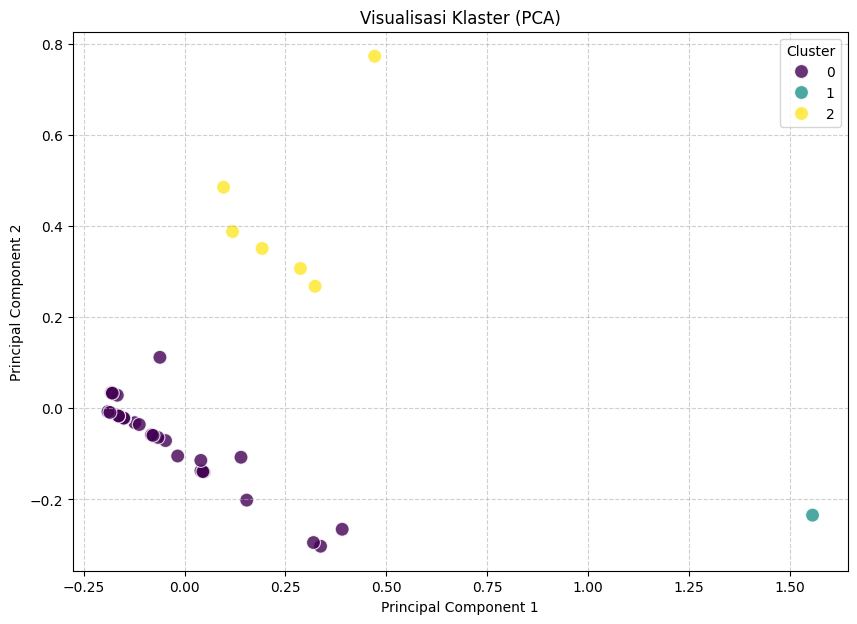

In [24]:
from sklearn.decomposition import PCA

# Apply PCA to reduce dimensions to 2 for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled_imputed)

# Create a DataFrame for easy plotting
pca_df = pd.DataFrame(data=X_pca, columns=['Principal Component 1', 'Principal Component 2'])
pca_df['Cluster'] = cluster

plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='Principal Component 1',
    y='Principal Component 2',
    hue='Cluster',
    data=pca_df,
    palette='viridis',
    s=100,
    alpha=0.8
)
plt.title('Visualisasi Klaster (PCA)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Dari visualisasi di atas, kita dapat melihat bagaimana klaster-klaster terpisah dalam ruang 2-dimensi yang direduksi oleh PCA. Ini membantu untuk memahami pemisahan visual antar klaster.

##**8. Strategi Pemasaran Berdasarkan Hasil Clustering**

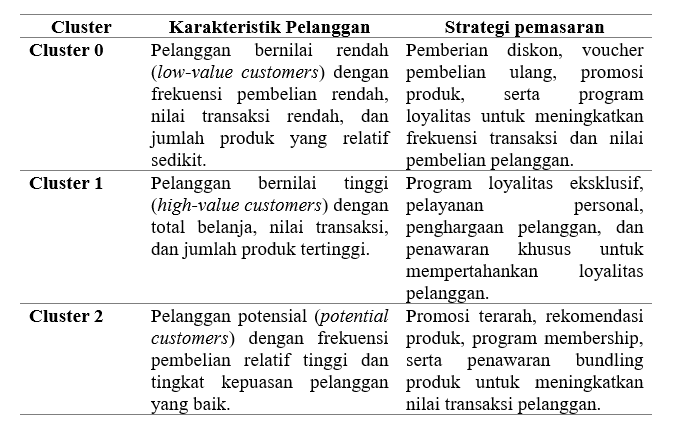

